## Kluczowe insighty z EDA (PaySim)

1. **Skrajna niezbalansowanie klas**: fraud stanowi 0.13% wszystkich transakcji (8213 z 6 362 620) — standardowe metryki jak accuracy są bezużyteczne, potrzebne PR-AUC/recall.

2. **Fraud występuje wyłącznie w dwóch typach transakcji**: TRANSFER (4097 przypadków) i CASH_OUT (4116 przypadków) — CASH_IN, DEBIT i PAYMENT nie zawierają fraudu w ogóle.

3. **Silny sygnał: zerowe saldo odbiorcy mimo wpływu środków.** Wśród transakcji CASH_OUT/TRANSFER, gdzie saldo odbiorcy nie zmienia się (oldbalanceDest = newbalanceDest = 0) mimo dodatniej kwoty, aż 70.5% to fraud (vs bazowe 0.13%) — klasyczny wzorzec konta-słupa (mule account).

4. **Odwrotny sygnał po stronie nadawcy**: gdy saldo nadawcy się NIE zmienia mimo wysłania środków, fraud występuje w zaledwie 0.002% przypadków — sprawcy niemal zawsze aktywnie opróżniają konto, więc "brak zmiany salda nadawcy" praktycznie wyklucza fraud.

5. **Rozkład kwot różni się kształtem**: fraud silniej koncentruje się w niskich kwotach, z dodatkowym skupiskiem przy bardzo wysokich wartościach — sugeruje predykcyjną wartość cechy `amount`.

6. **Ograniczenie datasetu**: PaySim generuje 1-3 transakcje na konto (symulacja, nie prawdziwa historia klienta), więc klasyczne velocity checks (częstotliwość transakcji w czasie) nie mają tu zastosowania — świadome ograniczenie do odnotowania.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/paysim.csv')

print(df.shape)
df.head()

(6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [2]:
df['isFraud'].value_counts(normalize=True) * 100

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

In [3]:
df.groupby('type')['isFraud'].sum()

type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isFraud, dtype: int64

In [4]:
#blad salda odbiorcy i nadawcy 

df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

In [5]:
df.groupby('isFraud')[['errorBalanceOrig', 'errorBalanceDest']].mean()

,errorBalanceOrig,errorBalanceDest
isFraud,,
0,201338.558109,54692.231734
1,10692.325265,732509.301069


In [6]:
zero_balance_dest = df[(df['oldbalanceDest'] == 0) & (df['newbalanceDest'] == 0) & (df['amount'] > 0)]
print(zero_balance_dest['isFraud'].value_counts(normalize=True) * 100)

isFraud
0    99.824363
1     0.175637
Name: proportion, dtype: float64


In [7]:
df['nameDest'].str.startswith('M').value_counts()

nameDest
False    4211125
True     2151495
Name: count, dtype: int64

In [8]:
zero_balance_dest_relevant = df[
    (df['oldbalanceDest'] == 0) & 
    (df['newbalanceDest'] == 0) & 
    (df['amount'] > 0) &
    (df['type'].isin(['CASH_OUT', 'TRANSFER']))
]
print(zero_balance_dest_relevant['isFraud'].value_counts(normalize=True) * 100)

isFraud
1    70.463989
0    29.536011
Name: proportion, dtype: float64


In [9]:
df['zero_balance_dest_flag'] = (
    (df['oldbalanceDest'] == 0) & 
    (df['newbalanceDest'] == 0) & 
    (df['amount'] > 0) &
    (df['type'].isin(['CASH_OUT', 'TRANSFER']))
).astype(int)

In [10]:
zero_change_orig = df[(df['oldbalanceOrg'] == df['newbalanceOrig']) & (df['amount'] > 0)]
print(zero_change_orig['isFraud'].value_counts(normalize=True) * 100)

isFraud
0    99.998037
1     0.001963
Name: proportion, dtype: float64


In [11]:
#praktycznie wszystkie transakcje, gdzie saldo nadawcy sie nie zmienia to legalne transakcje. 
#Sa to prawdopodobnie płatności do merchantów typu payment, gdzie system inaczej księguje saldo.

In [12]:
df['hour_of_day'] = df['step'] % 24

fraud_by_hour = df.groupby('hour_of_day')['isFraud'].agg(['sum', 'mean'])
print(fraud_by_hour)

             sum      mean
hour_of_day               
0            300  0.004191
1            358  0.013205
2            372  0.041251
3            326  0.162431
4            274  0.220790
5            366  0.223035
6            358  0.104678
7            328  0.036493
8            368  0.013673
9            341  0.001203
10           375  0.000881
11           324  0.000726
12           339  0.000701
13           346  0.000739
14           353  0.000803
15           341  0.000818
16           345  0.000781
17           353  0.000802
18           343  0.000591
19           342  0.000528
20           340  0.000614
21           347  0.001400
22           351  0.001804
23           323  0.002287


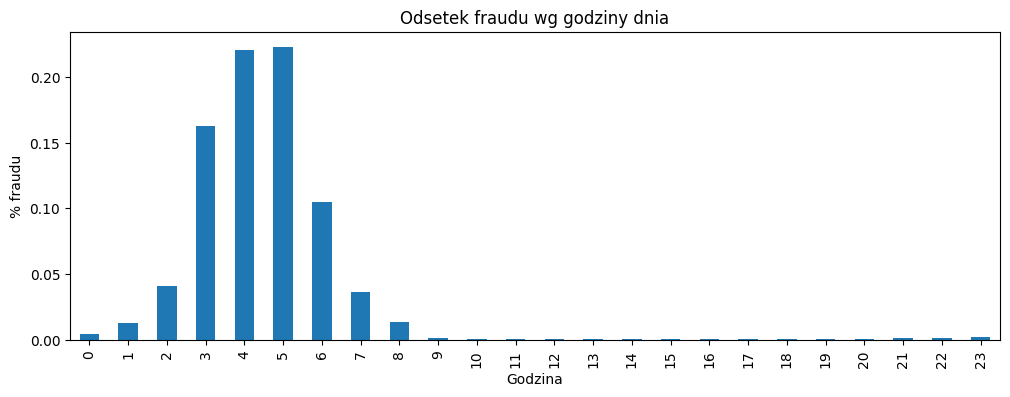

In [13]:
import matplotlib.pyplot as plt

fraud_by_hour['mean'].plot(kind='bar', figsize=(12,4))
plt.title('Odsetek fraudu wg godziny dnia')
plt.xlabel('Godzina')
plt.ylabel('% fraudu')
plt.show()

In [14]:
#z racji na mniejsza liczbę transakcji w nocy i nad ranem, pomimo stosunkowo stabilnej liczby fraudów 

In [15]:
df.groupby('isFraud')['amount'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


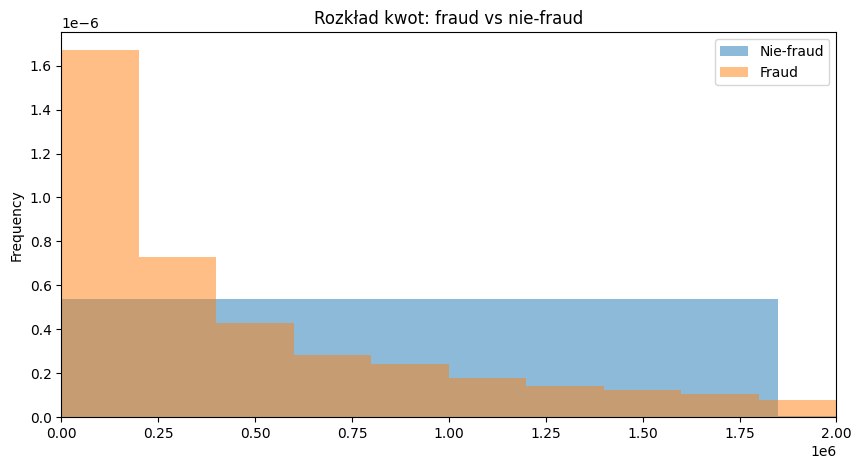

In [16]:
plt.figure(figsize=(10,5))
df[df['isFraud']==0]['amount'].plot(kind='hist', bins=50, alpha=0.5, label='Nie-fraud', density=True)
df[df['isFraud']==1]['amount'].plot(kind='hist', bins=50, alpha=0.5, label='Fraud', density=True)
plt.legend()
plt.xlim(0, 2000000)  # ograniczone X, bo outliery rozjadą skalę
plt.title('Rozkład kwot: fraud vs nie-fraud')
plt.show()

In [17]:
#Fraud silniej koncentruje sie w nizszym przedziale niż legalne transakcje 

In [18]:
df['nameOrig'].value_counts().head(10)

nameOrig
C1902386530    3
C363736674     3
C545315117     3
C724452879     3
C1784010646    3
C1677795071    3
C1462946854    3
C1999539787    3
C2098525306    3
C400299098     3
Name: count, dtype: int64

In [19]:
#Paysim symuluje pojedyńcze transakcje per konto, wiec klasyczne metody velocty nie maja tu zastosowania. 
#Do pełnego wdrożenia potrzebny byłby dataset z historia transakcyjna per klient

In [20]:
#Reguła 1: zerowe saldo odbiorcy mimo wpływu środków
df['rule_zero_balance_dest'] = (
    (df['oldbalanceDest'] == 0) & 
    (df['newbalanceDest'] == 0) & 
    (df['amount'] > 0) &
    (df['type'].isin(['CASH_OUT', 'TRANSFER']))
).astype(int)

#Reguła 2: duży błąd salda odbiorcy
threshold_dest = df['errorBalanceDest'].quantile(0.95)  # top 5% jako próg
df['rule_high_error_dest'] = (df['errorBalanceDest'].abs() > threshold_dest).astype(int)

#Reguła 3: "structuring" — kwota tuż poniżej okrągłego progu 
#np. transakcje blisko typowych limitów raportowania
df['rule_near_threshold'] = df['amount'].apply(
    lambda x: 1 if (9000 <= x <= 10000) or (49000 <= x <= 50000) else 0
)

#Reguła 4: pełne opróżnienie konta nadawcy (sprawca wypłaca wszystko)
df['rule_full_drain'] = (
    (df['newbalanceOrig'] == 0) & 
    (df['oldbalanceOrg'] > 0) &
    (df['type'].isin(['CASH_OUT', 'TRANSFER']))
).astype(int)

In [21]:
for rule in ['rule_zero_balance_dest', 'rule_high_error_dest', 'rule_near_threshold', 'rule_full_drain']:
    print(f"\n{rule}:")
    print(df[df[rule]==1]['isFraud'].value_counts(normalize=True) * 100)


rule_zero_balance_dest:
isFraud
1    70.463989
0    29.536011
Name: proportion, dtype: float64

rule_high_error_dest:
isFraud
0    99.442569
1     0.557431
Name: proportion, dtype: float64

rule_near_threshold:
isFraud
0    99.95875
1     0.04125
Name: proportion, dtype: float64

rule_full_drain:
isFraud
0    99.325631
1     0.674369
Name: proportion, dtype: float64


In [22]:
df['aml_rule_score'] = (
    df['rule_zero_balance_dest'] + 
    df['rule_high_error_dest'] + 
    df['rule_near_threshold'] + 
    df['rule_full_drain']
)

In [23]:
caught_by_rules = df[df['aml_rule_score'] > 0]
total_fraud = df['isFraud'].sum()
fraud_caught = caught_by_rules['isFraud'].sum()
print(f"Reguły wychwytuja {fraud_caught}/{total_fraud} fraudów ({fraud_caught/total_fraud*100:.1f}%)")

Reguły wychwytuja 8173/8213 fraudów (99.5%)


In [24]:
total_flagged = len(caught_by_rules)
precision = fraud_caught / total_flagged * 100
print(f"Reguły oflagowały {total_flagged} transakcji, z czego faktyczny fraud: {precision:.2f}%")

Reguły oflagowały 1652444 transakcji, z czego faktyczny fraud: 0.49%


In [25]:
#Reguły oparte na wiedzy AML, ale przy okazji oflagowały mnóstwo zwykłych, legalnych transakcji.
#Tylko 0,49% oflagowanych transakcji to faktyczny fraud. 1,65 mln fałszywych alarmów. 

In [26]:
%pip install "xgboost==1.7.6" --quiet


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [27]:
#tabela cech 
import pandas as pd
import numpy as np

#kopiujemy tylko potrzebne kolumny, żeby nie zaśmiecać oryginalnego df
features = df[[
    'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest',
    'errorBalanceOrig', 'errorBalanceDest',
    'rule_zero_balance_dest', 'rule_high_error_dest',
    'rule_near_threshold', 'rule_full_drain',
    'isFraud'
]].copy()

#one-hot encoding dla kolumny 'type' (kategoryczna -> liczby)
features = pd.get_dummies(features, columns=['type'], drop_first=True)

print(features.shape)
features.head()

(6362620, 16)


,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,errorBalanceOrig,errorBalanceDest,rule_zero_balance_dest,rule_high_error_dest,rule_near_threshold,rule_full_drain,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,9839.64,170136.0,160296.36,0.0,0.0,0.0,9839.64,0,0,1,0,0,False,False,True,False
1,1864.28,21249.0,19384.72,0.0,0.0,0.0,1864.28,0,0,0,0,0,False,False,True,False
2,181.00,181.0,0.00,0.0,0.0,0.0,181.00,1,0,0,1,1,False,False,False,True
3,181.00,181.0,0.00,21182.0,0.0,0.0,21363.00,0,0,0,1,1,True,False,False,False
4,11668.14,41554.0,29885.86,0.0,0.0,0.0,11668.14,0,0,0,0,0,False,False,True,False


In [28]:
from sklearn.model_selection import train_test_split

X = features.drop('isFraud', axis=1)
y = features['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # kluczowe — zachowuje proporcję fraudu w obu zbiorach
)

print(f"Train: {X_train.shape}, fraud: {y_train.sum()}")
print(f"Test: {X_test.shape}, fraud: {y_test.sum()}")

Train: (5090096, 15), fraud: 6570
Test: (1272524, 15), fraud: 1643


In [ ]:
from xgboost import XGBClassifier

# scale_pos_weight kompensuje niezbalansowanie (stosunek klasy 0 do klasy 1)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.1f}")

model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',  # PR-AUC zamiast domyślnej accuracy-oriented metryki
    random_state=42,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1
)

model.fit(X_train, y_train)

scale_pos_weight: 773.7


In [ ]:
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    average_precision_score, roc_auc_score
)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print(f"\nPR-AUC: {average_precision_score(y_test, y_pred_proba):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

In [ ]:
# ile transakcji model oflagował vs reguły
model_flagged = y_pred.sum()
model_fraud_caught = ((y_pred == 1) & (y_test == 1)).sum()
model_precision = model_fraud_caught / model_flagged * 100

print(f"Model XGBoost oflagował: {model_flagged} transakcji")
print(f"Z czego faktyczny fraud: {model_precision:.2f}%")
print(f"\nDla porównania — same reguły: precyzja 0.49%")

In [ ]:
%pip install --upgrade shap --quiet

In [ ]:
import shap
print(shap.__version__)

In [ ]:
import xgboost
print(xgboost.__version__)

In [ ]:
import shap

explainer = shap.TreeExplainer(model)
# na próbce, bo cały test set (1.27 mln wierszy) będzie wolny
sample = X_test.sample(2000, random_state=42)
shap_values = explainer.shap_values(sample)

shap.summary_plot(shap_values, sample)

In [ ]:
import joblib

joblib.dump(model, 'fraud_model.pkl')
X_test.to_csv('X_test.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

In [ ]:
%pip install streamlit --quiet

In [ ]:
import streamlit as st
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

st.set_page_config(page_title="AML Fraud Detection Dashboard", layout="wide")
st.title("AML Fraud Detection Dashboard")
st.markdown("System wykrywania fraudu na danych transakcyjnych PaySim — XGBoost + SHAP")

# --- wczytanie modelu i danych ---
@st.cache_resource
def load_model():
    return joblib.load('fraud_model.pkl')

@st.cache_data
def load_data():
    X_test = pd.read_csv('X_test.csv')
    y_test = pd.read_csv('y_test.csv')
    return X_test, y_test

model = load_model()
X_test, y_test = load_data()

# --- predykcje ---
y_pred_proba = model.predict_proba(X_test)[:, 1]
X_test['fraud_probability'] = y_pred_proba
X_test['actual_fraud'] = y_test.values

# --- panel boczny: filtr progu ryzyka ---
st.sidebar.header("Ustawienia")
threshold = st.sidebar.slider("Próg ryzyka (prawdopodobieństwo fraudu)", 0.0, 1.0, 0.5, 0.01)

flagged = X_test[X_test['fraud_probability'] >= threshold].sort_values(
    'fraud_probability', ascending=False
)

# --- metryki na górze ---
col1, col2, col3 = st.columns(3)
col1.metric("Oflagowane transakcje", len(flagged))
col2.metric("Faktyczny fraud wśród oflagowanych", int(flagged['actual_fraud'].sum()))
precision = flagged['actual_fraud'].mean() * 100 if len(flagged) > 0 else 0
col3.metric("Precyzja", f"{precision:.1f}%")

# --- tabela oflagowanych transakcji ---
st.subheader("Oflagowane transakcje")
st.dataframe(
    flagged[['amount', 'fraud_probability', 'actual_fraud']].head(50),
    use_container_width=True
)

# --- wyjaśnienie SHAP dla wybranej transakcji ---
st.subheader("Uzasadnienie decyzji (SHAP)")
if len(flagged) > 0:
    idx = st.selectbox("Wybierz transakcję do wyjaśnienia (indeks)", flagged.index[:20])
    
    explainer = shap.TreeExplainer(model)
    row = X_test.drop(['fraud_probability', 'actual_fraud'], axis=1).loc[[idx]]
    shap_values = explainer.shap_values(row)
    
    fig, ax = plt.subplots(figsize=(10, 4))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[0],
            base_values=explainer.expected_value,
            data=row.iloc[0],
            feature_names=row.columns.tolist()
        ),
        show=False
    )
    st.pyplot(fig)
else:
    st.info("Brak transakcji powyżej wybranego progu ryzyka.")
    